# Semantic Relevance in Product Ranking

The reference ranker uses lexical and structured signals. The semantic ranker adds one feature:

`semantic_similarity = cosine(query embedding, product-title embedding)`

The question is simple:

> **Did semantic similarity improve ranking, and what kinds of queries benefited most?**

Both models are frozen and evaluated on the same validation candidates. No retraining happens in this notebook, and the official ESCI test is untouched.


In [4]:
from pathlib import Path
import json

import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display

import sys

ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.evaluation.semantic_diagnostics import (
    annotate_diagnostic_queries,
    summarize_segments,
)

METRICS = ROOT / "artifacts" / "metrics"
FEATURES_DIR = ROOT / "artifacts" / "features"
EXAMPLES_DIR = ROOT / "artifacts" / "examples"

summary = json.loads((METRICS / "semantic_ranker_summary.json").read_text())
comparison = json.loads((METRICS / "semantic_vs_reference.json").read_text())

per_query = pd.read_csv(METRICS / "semantic_ranker_per_query.csv")
importance = pd.read_csv(METRICS / "semantic_feature_importance.csv")
examples = pd.read_csv(EXAMPLES_DIR / "semantic_query_examples.csv")
candidates = pd.read_parquet(
    FEATURES_DIR / "validation_features_semantic.parquet"
)

print(f"Validation queries: {len(per_query):,}")
print("Models retrained here: NO")
print("Official ESCI test used: NO")


Validation queries: 3,134
Models retrained here: NO
Official ESCI test used: NO


## 1. Did semantic similarity help?

Yes. The semantic model improves all three ranking metrics, with the largest headline gain in NDCG@10.


In [5]:
results = pd.DataFrame(
    [
        {"Model": "Reference LTR", **summary["Reference LTR"]},
        {"Model": "Semantic LTR", **summary["Semantic LTR"]},
    ]
).set_index("Model")

display(results.round(4))

print(f"Mean ΔNDCG@10:   {comparison['mean_delta']:+.4f}")
print(f"Median ΔNDCG@10: {comparison['median_delta']:+.4f}")
print(
    "95% bootstrap CI: "
    f"[{comparison['bootstrap_ci_95'][0]:+.4f}, "
    f"{comparison['bootstrap_ci_95'][1]:+.4f}]"
)
print(
    f"Wins / losses / ties: "
    f"{comparison['wins']} / {comparison['losses']} / {comparison['ties']}"
)


,ndcg@10,recall@10,mrr
Model,,,
Reference LTR,0.8236,0.5929,0.9089
Semantic LTR,0.8441,0.6086,0.9277


Mean ΔNDCG@10:   +0.0205
Median ΔNDCG@10: +0.0036
95% bootstrap CI: [+0.0173, +0.0236]
Wins / losses / ties: 1677 / 1205 / 252


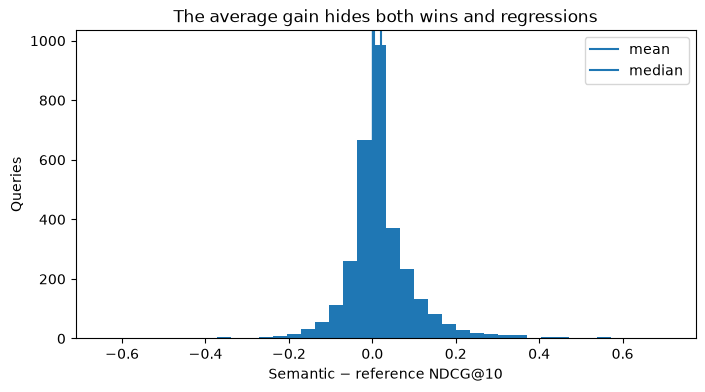

In [6]:
plt.figure(figsize=(8, 4))
plt.hist(per_query["delta_ndcg_at_10"], bins=40)
plt.axvline(0, linewidth=1)
plt.axvline(comparison["mean_delta"], linewidth=1.5, label="mean")
plt.axvline(comparison["median_delta"], linewidth=1.5, label="median")
plt.xlabel("Semantic − reference NDCG@10")
plt.ylabel("Queries")
plt.title("The average gain hides both wins and regressions")
plt.legend()
plt.show()


The average improvement is positive, but it is not universal. That makes the next question more useful than the overall score:

> **Where does semantics help most?**


## 2. Where does semantics help?

We look at four simple query characteristics:

- **query length**
- **lexical overlap** between the query and judged-relevant titles
- **semantic vs. TF-IDF disagreement**
- **identifier-style queries** containing numbers or model-like tokens

These are descriptive slices, not causal effects.


,slice,segment,n_queries,delta_ndcg_at_10
0,Query length,1 token,100,0.0234
1,Query length,2–3 tokens,1377,0.0211
2,Query length,4+ tokens,1657,0.0198
3,Lexical overlap,high,369,0.0086
4,Lexical overlap,low,1283,0.0356
5,Lexical overlap,medium,1482,0.0104
6,Semantic vs TF-IDF,high agreement,1311,0.0122
7,Semantic vs TF-IDF,high disagreement,427,0.0441
8,Semantic vs TF-IDF,mixed,1312,0.0194
9,Semantic vs TF-IDF,undefined,84,0.0473


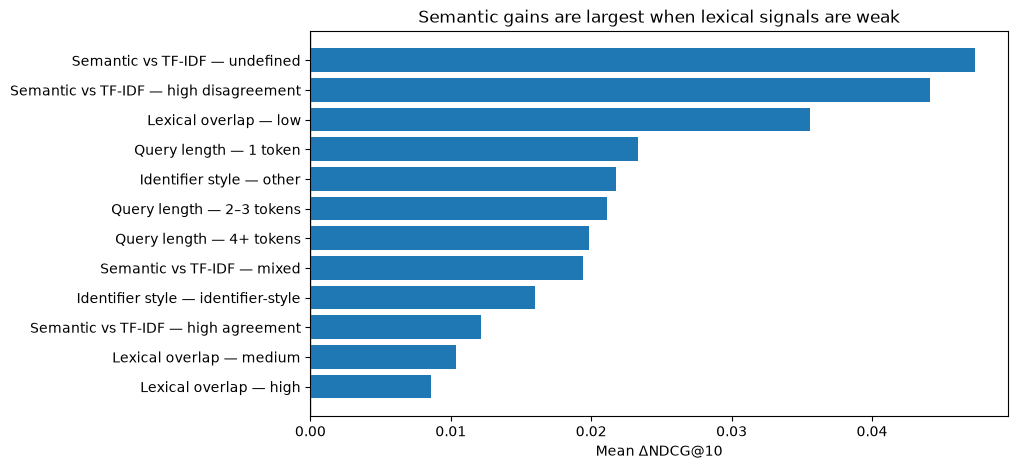

In [7]:
annotated = annotate_diagnostic_queries(per_query, candidates)

slice_names = {
    "query_length_segment": "Query length",
    "overlap_segment": "Lexical overlap",
    "disagreement_segment": "Semantic vs TF-IDF",
    "identifier_segment": "Identifier style",
}

parts = []
for column, label in slice_names.items():
    part = summarize_segments(annotated, column).copy()
    part["slice"] = label
    parts.append(part)

segment_summary = pd.concat(parts, ignore_index=True)

display(
    segment_summary[
        ["slice", "segment", "n_queries", "delta_ndcg_at_10"]
    ].round(4)
)

plot = segment_summary.sort_values("delta_ndcg_at_10")
labels = plot["slice"] + " — " + plot["segment"].astype(str)

plt.figure(figsize=(9, 5))
plt.barh(labels, plot["delta_ndcg_at_10"])
plt.axvline(0, linewidth=1)
plt.xlabel("Mean ΔNDCG@10")
plt.title("Semantic gains are largest when lexical signals are weak")
plt.show()


The main pattern to look for is whether semantic gains are larger when lexical overlap is low or when semantic and TF-IDF rankings disagree. That is the behavior we would expect if embeddings are adding information rather than duplicating lexical scores.


## 3. Does the model actually use the semantic feature?

Feature importance is descriptive, but it is still useful as a sanity check: if `semantic_similarity` mattered little to the fitted ranker, a large evaluation gain would be suspicious.


,rank,feature,gain_importance
0,1,semantic_similarity,0.2633
1,2,tfidf_score,0.2607
2,3,query_token_coverage,0.1809
3,4,query_bullet_coverage,0.0531
4,5,brand_match,0.0380
5,6,bm25_score,0.0376
6,7,exact_query_in_title,0.0372
7,8,title_token_coverage,0.0363
8,9,token_length_difference,0.0351
9,10,title_token_count,0.0310


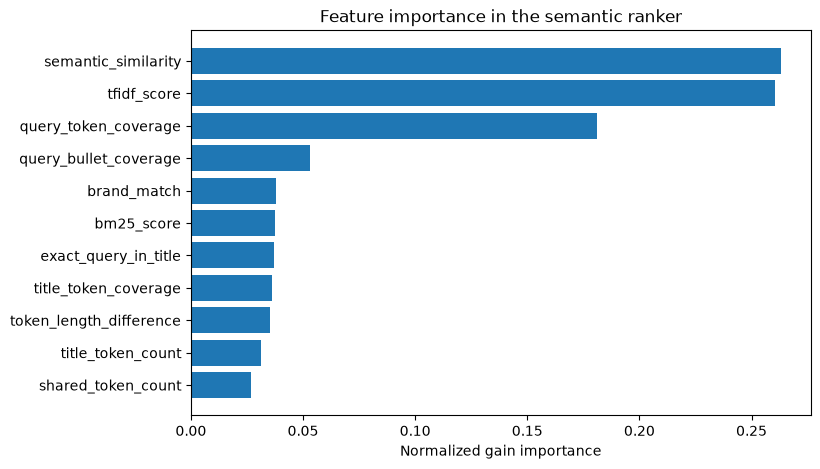

In [8]:
display(
    importance[
        ["rank", "feature", "gain_importance"]
    ].sort_values("rank").round(4)
)

plot = importance.sort_values("gain_importance")

plt.figure(figsize=(8, 5))
plt.barh(plot["feature"], plot["gain_importance"])
plt.xlabel("Normalized gain importance")
plt.title("Feature importance in the semantic ranker")
plt.show()


## 4. Concrete wins and regressions

Aggregate metrics explain **how much** the model improved. Candidate-level examples explain **why**.

The table below selects a few of the strongest saved examples and compares the semantic and reference rankings.


In [9]:
query_summary = (
    examples[
        ["kind", "query_id", "query", "delta_ndcg_at_10"]
    ]
    .drop_duplicates()
    .sort_values("delta_ndcg_at_10", ascending=False)
)

display(query_summary)

wins = query_summary[
    query_summary["kind"] == "large_improvement"
].head(2)

losses = query_summary[
    query_summary["kind"] == "large_regression"
].head(2)

chosen = pd.concat([wins, losses], ignore_index=True)

columns = [
    "semantic_rank",
    "reference_rank",
    "esci_label",
    "semantic_similarity",
    "tfidf_score",
    "product_title",
]

for row in chosen.itertuples(index=False):
    print(
        f"\n{row.kind}: {row.query} "
        f"(ΔNDCG@10={row.delta_ndcg_at_10:+.3f})"
    )
    view = examples[examples["query_id"] == row.query_id].copy()
    display(
        view[
            [column for column in columns if column in view.columns]
        ]
        .sort_values("semantic_rank")
        .head(6)
        .round(3)
    )


,kind,query_id,query,delta_ndcg_at_10
28,large_improvement,87542,rib anch,0.707518
0,large_improvement,5749,Since I have a desktop any laptop for work wit...,0.694500
12,large_improvement,78865,pentrrex 4oz,0.676521
108,tie,13881,batterie c,0.000000
92,tie,5958,a20,0.000000
124,tie,15107,best hyaluronic acid for lips,0.000000
60,large_regression,50912,holocaust fiction books,-0.372247
44,large_regression,46,"#9x5"" wood screws",-0.456229
76,large_regression,100955,tea bag dish alice,-0.643793



large_improvement: rib anch (ΔNDCG@10=+0.708)


,semantic_rank,reference_rank,esci_label,semantic_similarity,tfidf_score,product_title
28,1,4,E,0.385,0.000,All Natural Danish Baby Back Ribs
29,2,2,I,0.291,0.425,Sorbus Non-Stick Rib Rack – Porcelain Coated S...
30,3,12,E,0.387,0.000,"Wild Boar Baby Back Ribs - 5 lbs, 4 oz ribs"
31,4,1,I,0.298,0.254,Purina Busy Small/Medium Breed Dog Rawhide Tre...
32,5,15,E,0.332,0.000,"TenderBison Back Ribs, Each Rack Contains 7 Ri..."
33,6,13,E,0.256,0.000,Creekstone Farms Natural Duroc Pork Spare Ribs...



large_improvement: Since I have a desktop any laptop for work with decent specifications would do (ΔNDCG@10=+0.695)


,semantic_rank,reference_rank,esci_label,semantic_similarity,tfidf_score,product_title
0,1,9,E,0.579,0.045,Lenovo Chromebook C330 2-in-1 Convertible Lapt...
1,2,12,E,0.576,0.041,"Acer Aspire 5 Slim Laptop, 15.6 inches Full HD..."
2,3,11,E,0.552,0.043,"ASUS VivoBook L203MA Ultra-Thin Laptop, Intel ..."
3,4,1,I,0.335,0.224,ASURION 3 Year Desktop Computer Protection Pla...
4,5,10,I,0.431,0.000,"DELL Optiplex 990 SFF PC, Intel Core i5 Proces..."
5,6,4,I,0.351,0.255,GAOMON M10K PRO 10 x 6.25 Inches Art Digital G...



large_regression: holocaust fiction books (ΔNDCG@10=-0.372)


,semantic_rank,reference_rank,esci_label,semantic_similarity,tfidf_score,product_title
60,1,3,I,0.726,0.237,The Child of Auschwitz: Absolutely heartbreaki...
61,2,4,E,0.741,0.161,The Survivor: A Novel Based on a True Holocaus...
62,3,1,E,0.656,0.287,Last Words: Surviving the Holocaust
63,4,8,I,0.700,0.000,The Librarian of Auschwitz (Special Edition)
64,5,5,I,0.544,0.129,My Family's Survival: The true story of how th...
65,6,16,I,0.557,0.000,The Secret Orphan: The heartbreaking and gripp...



large_regression: #9x5" wood screws (ΔNDCG@10=-0.456)


,semantic_rank,reference_rank,esci_label,semantic_similarity,tfidf_score,product_title
44,1,5,I,0.277,0.0,ZINUS 9 Inch Metal Smart Box Spring / Mattress...
45,2,3,I,0.269,0.0,ZINUS Compack Metal Bed Frame / 7 Inch Support...
46,3,2,E,0.165,0.0,"DEWALT 20V Max Cordless Drill / Driver Kit, Co..."
47,4,10,I,0.222,0.0,Mounting Dream UL Listed TV Mount for Most 37-...
48,5,1,E,0.154,0.0,BLACK+DECKER 20V MAX Cordless Drill / Driver w...
49,6,6,I,0.204,0.0,VIVO Dual LCD LED 13 to 27 inch Monitor Desk M...


## 5. Takeaways

- **Semantic similarity adds real incremental value.** Validation NDCG@10 rises from **0.8236 to 0.8441**.
- The paired improvement is credible: the **95% bootstrap interval is entirely above zero**.
- The gain is not uniform. The most useful cases are queries where lexical matching is a weak signal or where semantic and lexical rankings disagree.
- Regressions still matter. Individual regressions show that semantic similarity can sometimes overemphasize broad relatedness when exact lexical constraints matter.
- This project is still **candidate re-ranking**, not full-catalog retrieval.

The practical conclusion is not that semantics should replace lexical matching. It is that **semantic and lexical signals are complementary**, which motivates carrying both into later retrieval work.

**Official ESCI test used: NO.**
